In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

data_path = '/content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset'

if os.path.exists(data_path):
    print(f"Contents of '{data_path}':")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"The directory '{data_path}' does not exist. Please check the path.")


Mounted at /content/drive
Contents of '/content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset':
orders.pkl
customers.pkl
order_items.pkl
payments.pkl
products.pkl
reviews.pkl
category_translation.pkl
geoloaction.pkl
sellers.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
orders = pd.read_pickle(os.path.join(data_path, 'orders.pkl'))
customers = pd.read_pickle(os.path.join(data_path, 'customers.pkl'))
order_items = pd.read_pickle(os.path.join(data_path, 'order_items.pkl'))
payments = pd.read_pickle(os.path.join(data_path, 'payments.pkl'))
products = pd.read_pickle(os.path.join(data_path, 'products.pkl'))
reviews = pd.read_pickle(os.path.join(data_path, 'reviews.pkl'))
sellers = pd.read_pickle(os.path.join(data_path, 'sellers.pkl'))
category_translation = pd.read_pickle(os.path.join(data_path, 'category_translation.pkl'))
geolocation = pd.read_pickle(os.path.join(data_path, 'geoloaction.pkl'))

print("All data files loaded successfully!")

Đã tải tất cả các tệp dữ liệu thành công!


In [ ]:
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Customers": customers,
    "Products": products,
    "Sellers": sellers,
    "Payments": payments,
    "Reviews": reviews,
    "Geolocation": geolocation
}

summary = pd.DataFrame({
    "Table": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Table,Rows,Columns
0,Orders,99441,8
1,Order Items,112650,7
2,Customers,99441,5
3,Products,32951,9
4,Sellers,3095,4
5,Payments,103886,5
6,Reviews,99224,7
7,Geolocation,1000163,5


#Marketplace Growth
**Business Questions**

- How is the marketplace operating at scale?
- How has the marketplace scale changed over time?
- Is GMV increasing due to more orders or higher average order value?

In [ ]:

df_master = pd.merge(orders, order_items, on='order_id', how='left')
df_master = pd.merge(df_master, customers, on='customer_id', how='left')
df_master = pd.merge(df_master, reviews, on='order_id', how='left')

# Display the first few rows and summary
print(f"Master DataFrame Shape: {df_master.shape}")
display(df_master.head())
df_master.info()

Master DataFrame Shape: (114092, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,no comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,no comment,no comment,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,no comment,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,no comment,no comment,2018-02-17,2018-02-18 13:02:51


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114092 non-null  object        
 1   customer_id                    114092 non-null  object        
 2   order_status                   114092 non-null  object        
 3   order_purchase_timestamp       114092 non-null  datetime64[ns]
 4   order_approved_at              113930 non-null  datetime64[ns]
 5   order_delivered_carrier_date   112112 non-null  datetime64[ns]
 6   order_delivered_customer_date  110839 non-null  datetime64[ns]
 7   order_estimated_delivery_date  114092 non-null  datetime64[ns]
 8   order_item_id                  113314 non-null  float64       
 9   product_id                     113314 non-null  object        
 10  seller_id                      113314 non-null  object        
 11  

In [ ]:
# Time Features
df_master['hour'] = df_master['order_purchase_timestamp'].dt.hour
df_master['day_of_week'] = df_master['order_purchase_timestamp'].dt.day_name()
df_master['month'] = df_master['order_purchase_timestamp'].dt.month_name()
df_master['month_num'] = df_master['order_purchase_timestamp'].dt.month
df_master['quarter'] = df_master['order_purchase_timestamp'].dt.quarter
df_master['year'] = df_master['order_purchase_timestamp'].dt.year

# Calculate GMV (Gross Merchandise Value)
df_master['gmv'] = df_master['price'] + df_master['freight_value']

# Display updated dataframe structure
display(df_master[['order_purchase_timestamp', 'hour', 'day_of_week', 'month', 'gmv']].head())

,order_purchase_timestamp,hour,day_of_week,month,gmv
0,2017-10-02 10:56:33,10,Monday,October,38.71
1,2018-07-24 20:41:37,20,Tuesday,July,141.46
2,2018-08-08 08:38:49,8,Wednesday,August,179.12
3,2017-11-18 19:28:06,19,Saturday,November,72.20
4,2018-02-13 21:18:39,21,Tuesday,February,28.62


### Marketplace Key Performance Indicators (KPIs)
Summary of total value, volume, and active participants.

In [ ]:
# Calculate KPIs
total_gmv = df_master['gmv'].sum()
total_orders = df_master['order_id'].nunique()
active_sellers = df_master['seller_id'].nunique()
active_customers = df_master['customer_unique_id'].nunique()
aov = total_gmv / total_orders

# Create a summary DataFrame
performance_kpis = pd.DataFrame({
    "Metric": [
        "Total GMV",
        "Total Orders",
        "Active Customers",
        "Active Sellers",
        "Average Order Value (AOV)"
    ],
    "Value": [
        f"R$ {total_gmv:,.2f}",
        f"{total_orders:,}",
        f"{active_customers:,}",
        f"{active_sellers:,}",
        f"R$ {aov:,.2f}"
    ]
})

performance_kpis

,Metric,Value
0,Total GMV,"R$ 15,915,872.32"
1,Total Orders,"99,441"
2,Active Customers,"96,096"
3,Active Sellers,"3,095"
4,Average Order Value (AOV),R$ 160.05


### Monthly Active Customers Trend
Tracking the number of unique customers who made a purchase each month.

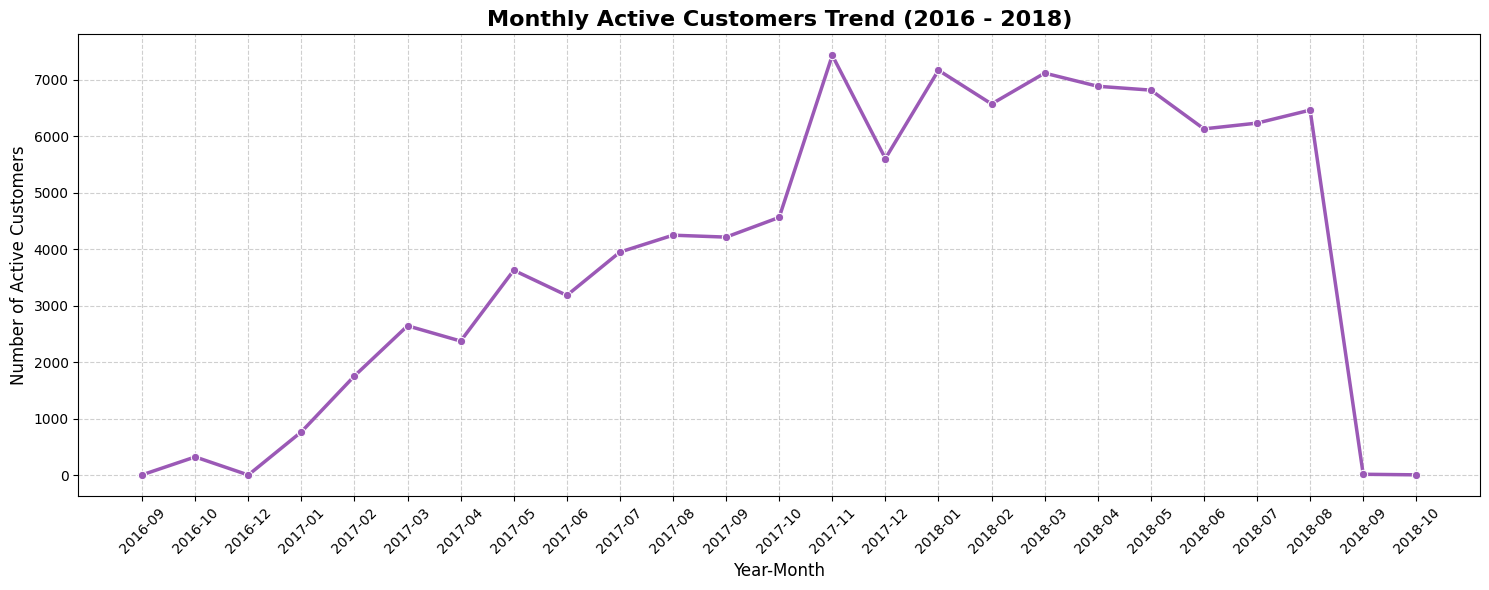

In [ ]:
# Calculate monthly active customers
monthly_customers = df_master.groupby(['year', 'month_num', 'month'])['customer_unique_id'].nunique().reset_index(name='active_customers')
monthly_customers['period'] = monthly_customers['year'].astype(str) + "-" + monthly_customers['month_num'].astype(str).str.zfill(2)
monthly_customers = monthly_customers.sort_values(['year', 'month_num'])

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_customers, x='period', y='active_customers', marker='o', color='#9b59b6', linewidth=2.5)

plt.title('Monthly Active Customers Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Active Customers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthly Orders Trend
Visualizing the number of orders over time to identify growth and seasonality.

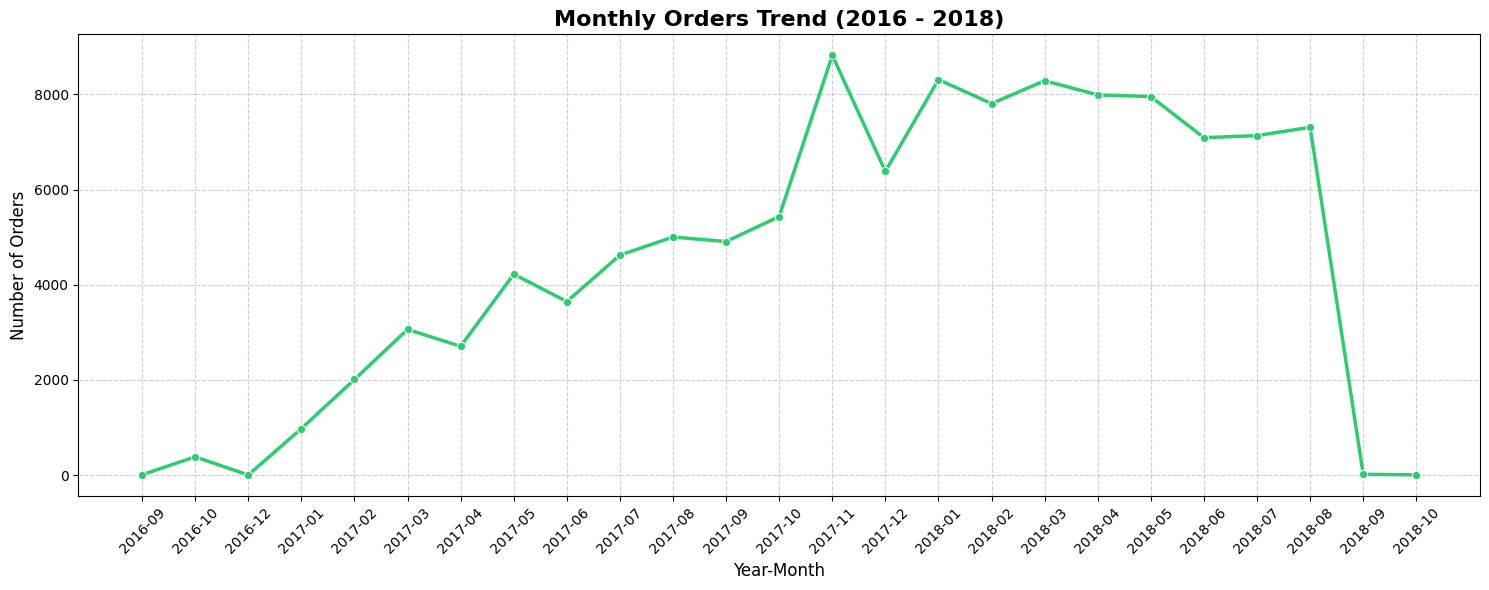

In [ ]:
monthly_trend = df_master.groupby(['year', 'month_num', 'month']).size().reset_index(name='order_count')
monthly_trend['period'] = monthly_trend['year'].astype(str) + "-" + monthly_trend['month_num'].astype(str).str.zfill(2)
monthly_trend = monthly_trend.sort_values(['year', 'month_num'])

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_trend, x='period', y='order_count', marker='o', color='#2ecc71', linewidth=2.5)

plt.title('Monthly Orders Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthly GMV Trend
Visualizing the total Gross Merchandise Value (Price + Freight) over time.

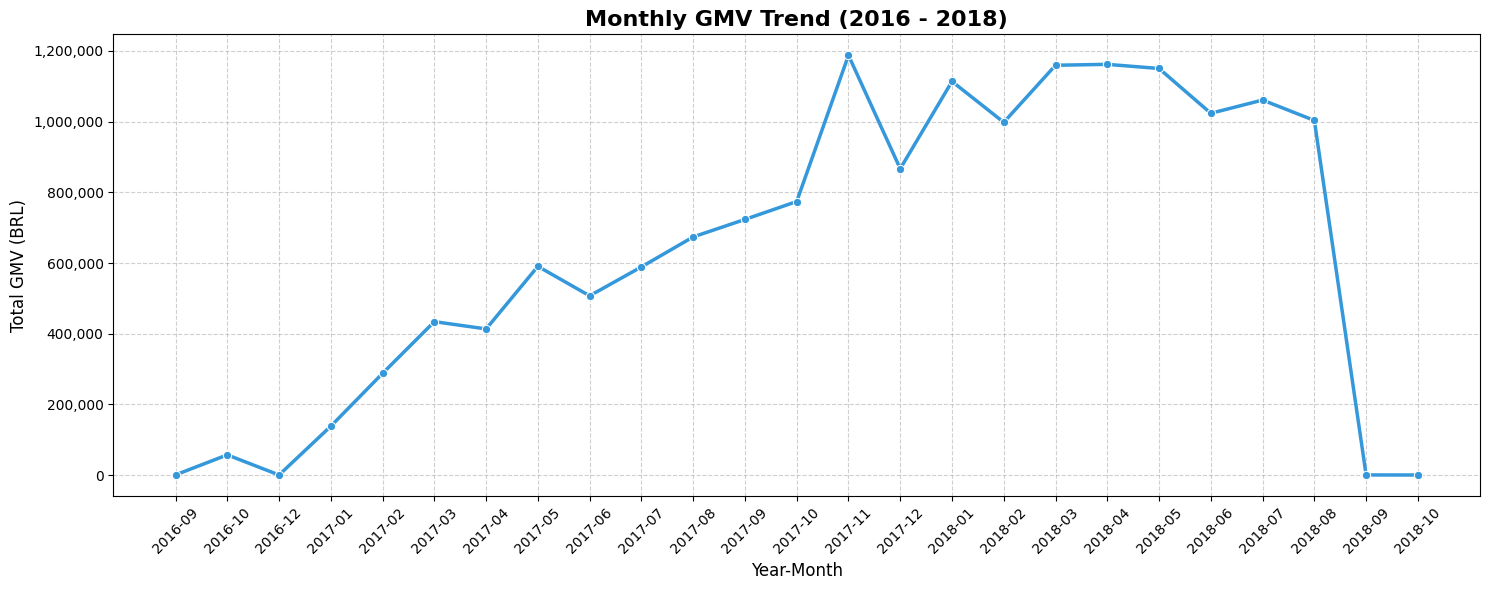

In [ ]:
# Calculate monthly GMV
monthly_gmv = df_master.groupby(['year', 'month_num', 'month'])['gmv'].sum().reset_index(name='total_gmv')
monthly_gmv['period'] = monthly_gmv['year'].astype(str) + "-" + monthly_gmv['month_num'].astype(str).str.zfill(2)
monthly_gmv = monthly_gmv.sort_values(['year', 'month_num'])

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_gmv, x='period', y='total_gmv', marker='o', color='#3498db', linewidth=2.5)

plt.title('Monthly GMV Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total GMV (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Quarterly GMV Trend
Bar chart showing the total Gross Merchandise Value (GMV) per quarter.

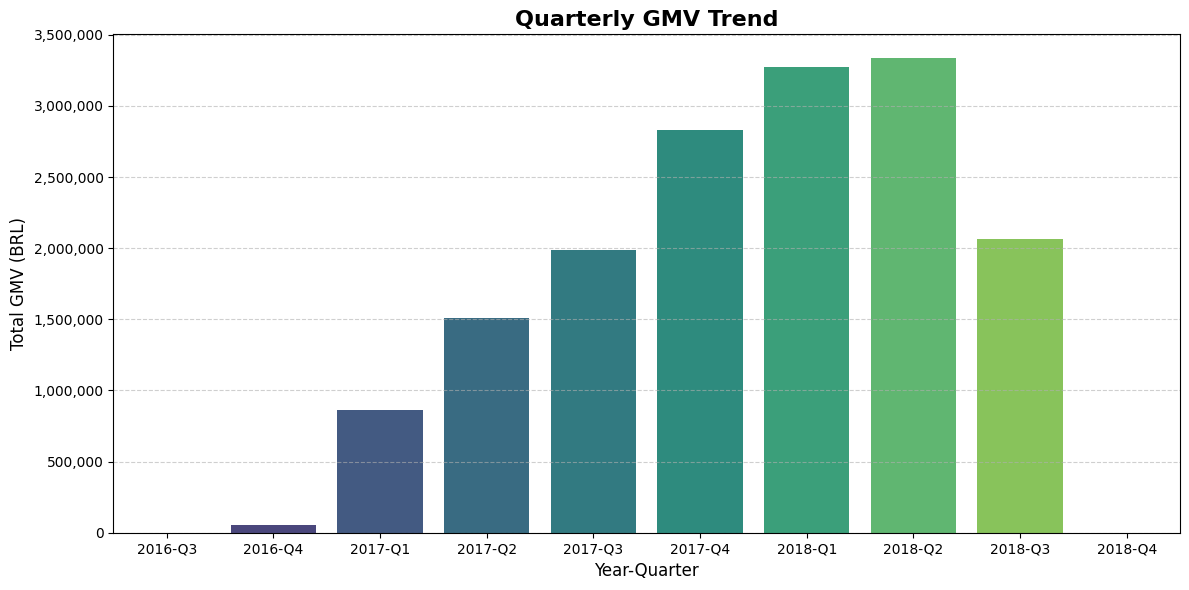

In [ ]:
# Calculate quarterly GMV
quarterly_gmv = df_master.groupby(['year', 'quarter'])['gmv'].sum().reset_index(name='total_gmv')
quarterly_gmv['period'] = quarterly_gmv['year'].astype(str) + "-Q" + quarterly_gmv['quarter'].astype(str)
quarterly_gmv = quarterly_gmv.sort_values(['year', 'quarter'])

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_gmv, x='period', y='total_gmv', palette='viridis', hue='period', legend=False)

plt.title('Quarterly GMV Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year-Quarter', fontsize=12)
plt.ylabel('Total GMV (BRL)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Format y-axis labels
from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Quarterly GMV Analysis
*   **Exponential Growth:** The marketplace experienced consistent quarter-over-quarter growth throughout 2017, reflecting rapid expansion and increasing market penetration.
*   **Peak Performance:** Revenue reached its highest levels in the first half of 2018 (Q1 and Q2), maintaining the momentum gained from the late 2017 holiday season.
*   **Q3 2018 Downturn:** The noticeable decline in 2018-Q3 aligns with logistical disruptions and external economic shocks (the 'Black Swan' event mentioned previously) that impacted the entire Brazilian e-commerce sector.

### Monthly Average Order Value (AOV) Trend
Tracking the average amount spent per order each month.

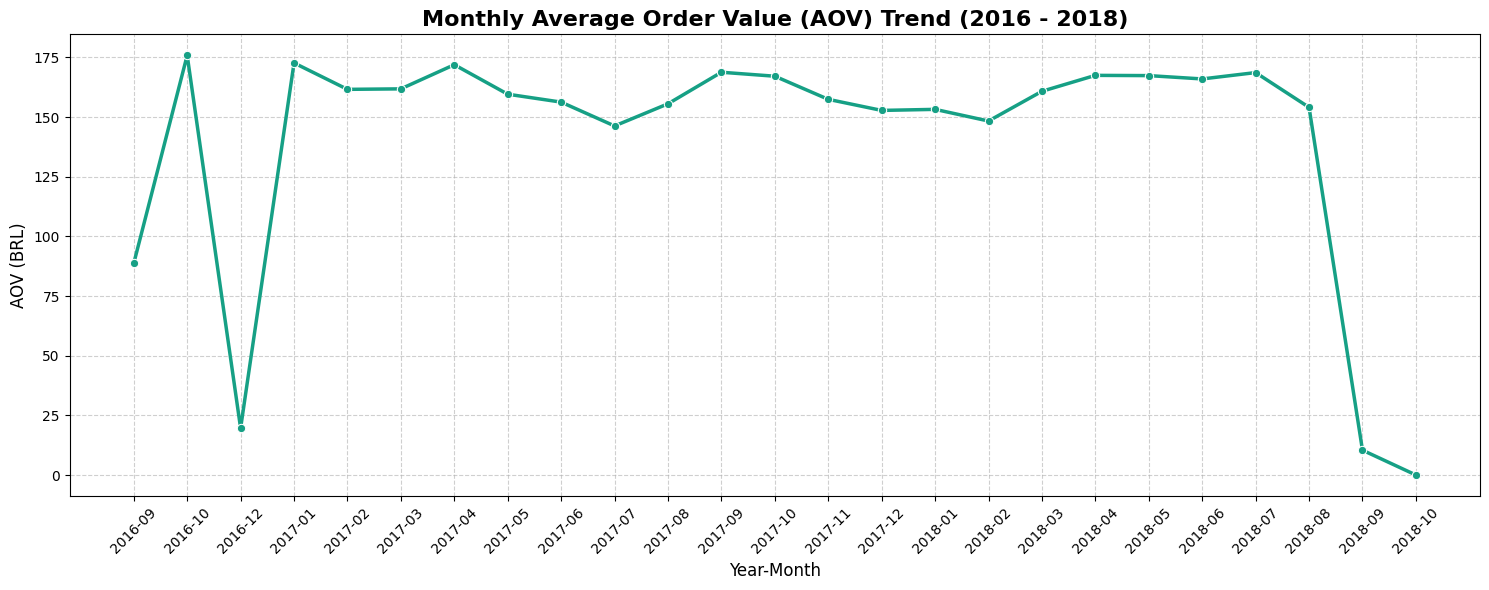

In [ ]:
# Group by period and calculate total gmv and unique orders
monthly_aov_data = df_master.groupby(['year', 'month_num', 'month']).agg(
    total_monthly_gmv=('gmv', 'sum'),
    total_monthly_orders=('order_id', 'nunique')
).reset_index()

monthly_aov_data['aov'] = monthly_aov_data['total_monthly_gmv'] / monthly_aov_data['total_monthly_orders']
monthly_aov_data['period'] = monthly_aov_data['year'].astype(str) + "-" + monthly_aov_data['month_num'].astype(str).str.zfill(2)
monthly_aov_data = monthly_aov_data.sort_values(['year', 'month_num'])

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_aov_data, x='period', y='aov', marker='o', color='#16a085', linewidth=2.5)

plt.title('Monthly Average Order Value (AOV) Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('AOV (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthly Active Sellers Trend
Tracking the number of unique sellers making sales each month.

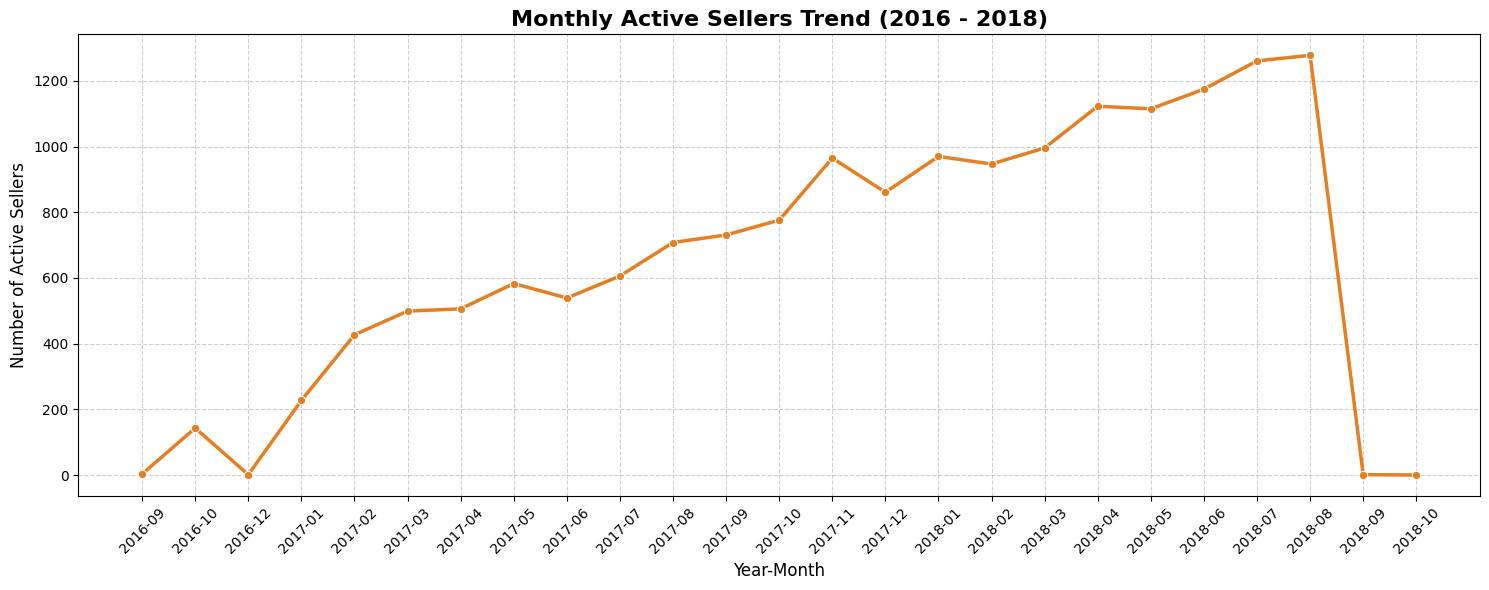

In [ ]:
# Calculate monthly active sellers
monthly_sellers = df_master.groupby(['year', 'month_num', 'month'])['seller_id'].nunique().reset_index(name='active_sellers')
monthly_sellers['period'] = monthly_sellers['year'].astype(str) + "-" + monthly_sellers['month_num'].astype(str).str.zfill(2)
monthly_sellers = monthly_sellers.sort_values(['year', 'month_num'])

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sellers, x='period', y='active_sellers', marker='o', color='#e67e22', linewidth=2.5)

plt.title('Monthly Active Sellers Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Active Sellers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Executive Summary: Marketplace Growth Answers

*   **How is the marketplace operating at scale?**
    The marketplace operates at a significant scale with over **R$ 15.9M in total GMV** and **99,441 orders**. The ecosystem is robust, supported by a diverse base of over **96,000 active customers** and **3,000 active sellers**.

*   **How has the marketplace scale changed over time?**
    The scale has shown consistent expansion from 2016 through mid-2018. Both **active customers and active sellers have increased steadily**, indicating healthy growth in both supply and demand. However, a significant logistical disruption in Q3 2018 (the truck drivers' strike) caused a temporary collapse in transaction volume despite the growing number of participants.

*   **Is GMV increasing due to more orders or higher average order value?**
    GMV growth is primarily driven by an **increase in the number of orders** rather than higher order values. While the total volume grew exponentially through 2017, the **Average Order Value (AOV) remained remarkably stable** (fluctuating around R$ 160). This suggests that Olist's growth comes from expanding its customer reach and order frequency rather than increasing the price per basket.

```markdown
# Seller Performance
### Business Questions
How has the seller ecosystem evolved over time?
```

In [ ]:
total_sellers = sellers['seller_id'].nunique()
active_sellers = df_master['seller_id'].nunique()

seller_first_order = (
    df_master.groupby('seller_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

seller_first_order['year'] = seller_first_order['order_purchase_timestamp'].dt.year
seller_first_order['month'] = seller_first_order['order_purchase_timestamp'].dt.month

monthly_new_sellers = (
    seller_first_order
    .groupby(['year','month'])
    .size()
    .reset_index(name='new_sellers')
)

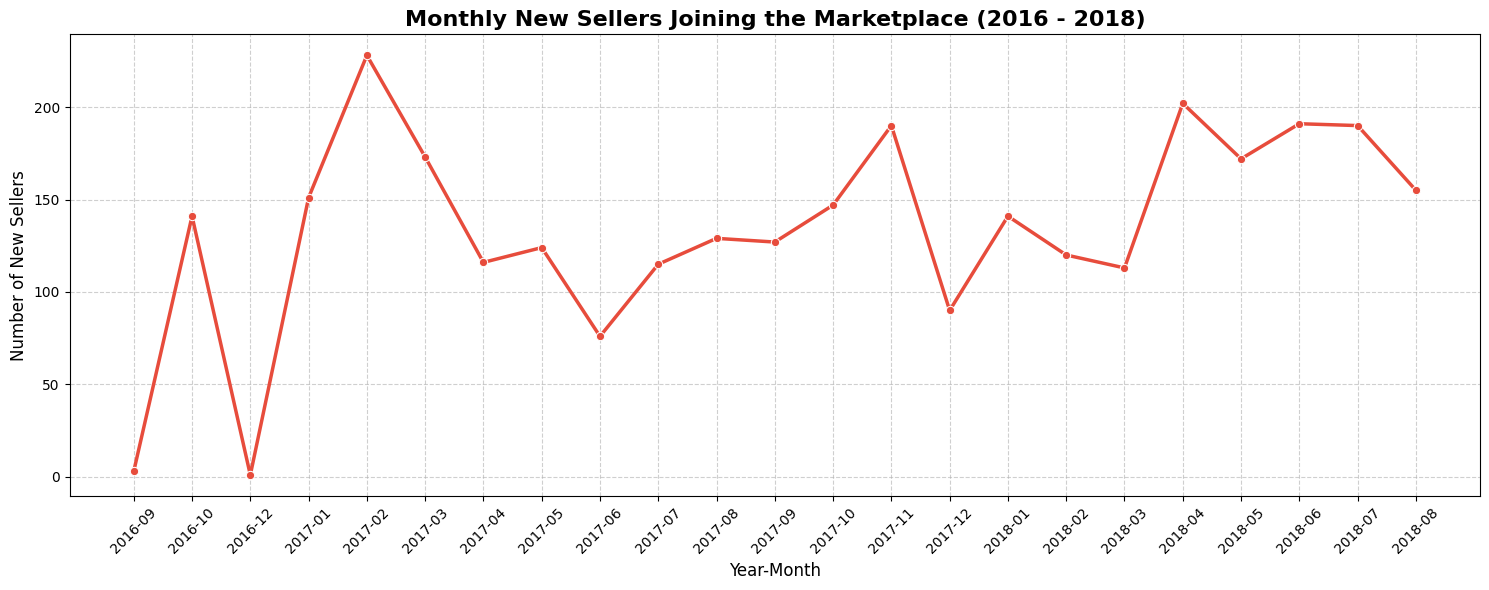

In [ ]:
# Prepare the period column for plotting
monthly_new_sellers['period'] = monthly_new_sellers['year'].astype(str) + "-" + monthly_new_sellers['month'].astype(str).str.zfill(2)
monthly_new_sellers = monthly_new_sellers.sort_values(['year', 'month'])

# Plotting the monthly new sellers trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_new_sellers, x='period', y='new_sellers', marker='o', color='#e74c3c', linewidth=2.5)

plt.title('Monthly New Sellers Joining the Marketplace (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of New Sellers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

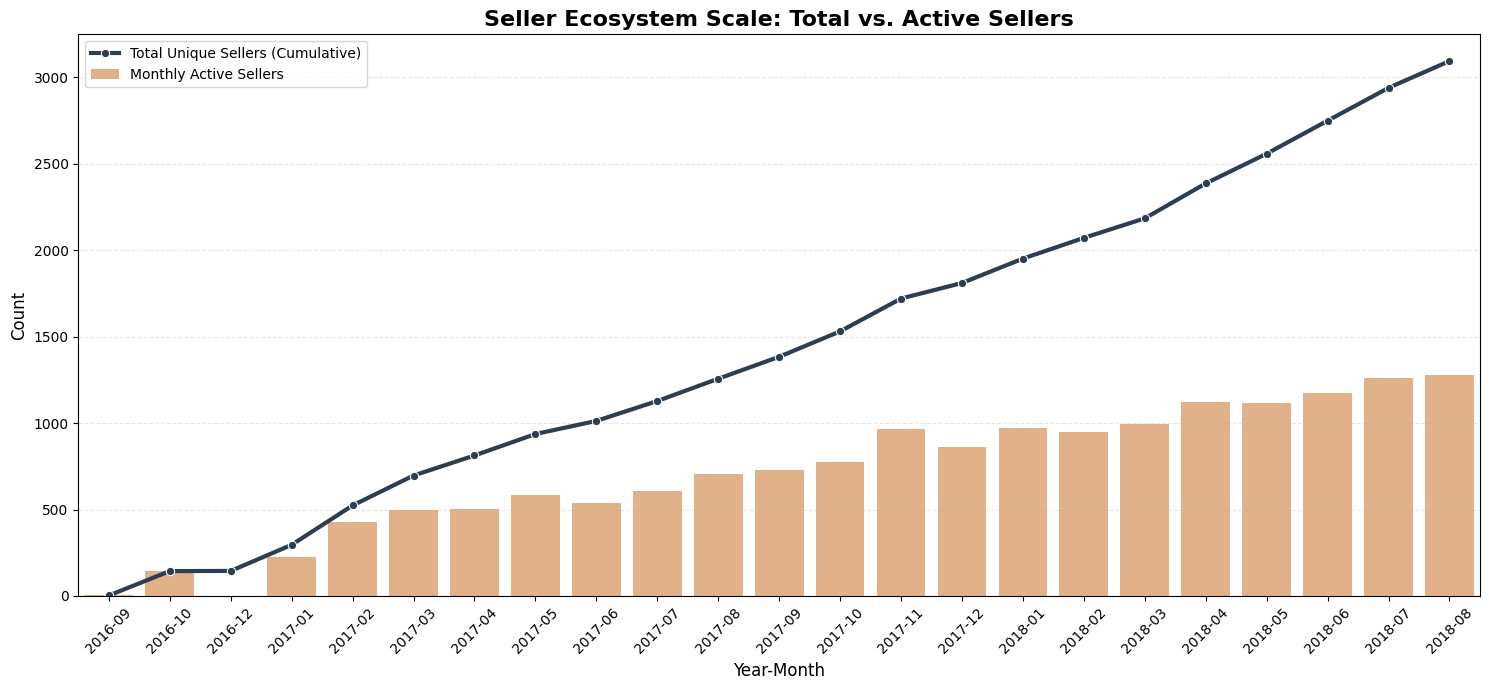

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate monthly active sellers (already exists in kernel but let's ensure consistency)
monthly_active_sellers = df_master.groupby(['year', 'month_num'])['seller_id'].nunique().reset_index(name='active_sellers')

# Calculate cumulative unique sellers over time
# Get the first month each seller appeared
seller_first_appearance = df_master.groupby('seller_id')['order_purchase_timestamp'].min().reset_index()
seller_first_appearance['year_month'] = seller_first_appearance['order_purchase_timestamp'].dt.to_period('M')

# Count new sellers per month and calculate cumulative sum
cumulative_sellers = seller_first_appearance.groupby('year_month').size().cumsum().reset_index(name='cumulative_total')
cumulative_sellers['year_month'] = cumulative_sellers['year_month'].astype(str)

# Merge with active sellers for a comparison plot
monthly_active_sellers['period'] = monthly_active_sellers['year'].astype(str) + "-" + monthly_active_sellers['month_num'].astype(str).str.zfill(2)
plot_data = pd.merge(cumulative_sellers, monthly_active_sellers[['period', 'active_sellers']], left_on='year_month', right_on='period', how='left')

# Plotting
plt.figure(figsize=(15, 7))

# Plot cumulative total
sns.lineplot(data=plot_data, x='year_month', y='cumulative_total', marker='o', label='Total Unique Sellers (Cumulative)', color='#2c3e50', linewidth=3)
# Plot monthly active
sns.barplot(data=plot_data, x='year_month', y='active_sellers', alpha=0.6, label='Monthly Active Sellers', color='#e67e22')

plt.title('Seller Ecosystem Scale: Total vs. Active Sellers', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insights: Seller Ecosystem Dynamics

*   **Continuous Seller Acquisition:** Olist continuously attracted new sellers throughout the observation period, although monthly onboarding volumes fluctuated.
*   **Growing Seller Ecosystem:** The cumulative seller base expanded steadily, surpassing 3,000 registered sellers by the end of the study period.
*   **Seller Activation Opportunity:** While the number of active sellers continued to increase, the widening gap between registered and active sellers suggests room to improve seller activation and long-term engagement.

### Business Questions
Are sellers contributing evenly to marketplace revenue?

In [ ]:
seller_summary = (
    df_master
    .groupby('seller_id')
    .agg(
        total_gmv=('gmv','sum'),
        total_orders=('order_id','nunique')
    )
    .reset_index()
)
seller_summary['gmv_per_order'] = seller_summary['total_gmv'] / seller_summary['total_orders']
seller_summary.head()

,seller_id,total_gmv,total_orders,gmv_per_order
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,916.020000
1,001cca7ae9ae17fb1caed9dfb1094831,33934.17,200,169.670850
2,001e6ad469a905060d959994f1b41e4f,267.94,1,267.940000
3,002100f778ceb8431b7a1020ff7ab48f,2060.85,51,40.408824
4,003554e2dce176b5555353e4f3555ac8,139.38,1,139.380000


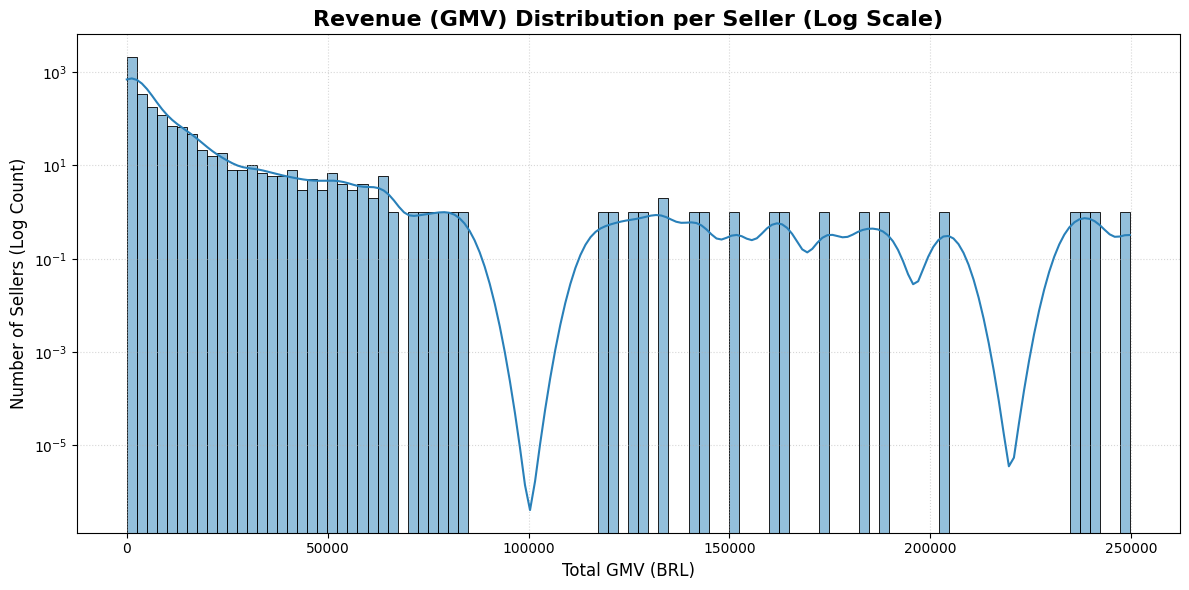

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of GMV per seller
plt.figure(figsize=(12, 6))
sns.histplot(seller_summary['total_gmv'], bins=100, kde=True, color='#2980b9')

# Adding log scale for better visualization due to high variance
plt.yscale('log')

plt.title('Revenue (GMV) Distribution per Seller (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Total GMV (BRL)', fontsize=12)
plt.ylabel('Number of Sellers (Log Count)', fontsize=12)
plt.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights
*   **Highly Uneven Revenue Distribution:** Most sellers generate relatively low GMV, while only a small number of sellers achieve exceptionally high sales.
*   **Long-Tail Seller Ecosystem:** The marketplace consists of a large population of small sellers and a limited number of high-performing sellers, reflecting a typical long-tail marketplace structure.
*   **Revenue Concentration:** The presence of a few extreme high-GMV sellers suggests that a significant share of marketplace revenue is concentrated among top-performing sellers.

###Business question
Is marketplace revenue concentrated among a few sellers?

In [ ]:
seller_summary = seller_summary.sort_values(
    'total_gmv',
    ascending=False
)

seller_summary['cum_gmv'] = seller_summary['total_gmv'].cumsum()

seller_summary['cum_pct'] = (
    seller_summary['cum_gmv']
    /
    seller_summary['total_gmv'].sum()
)

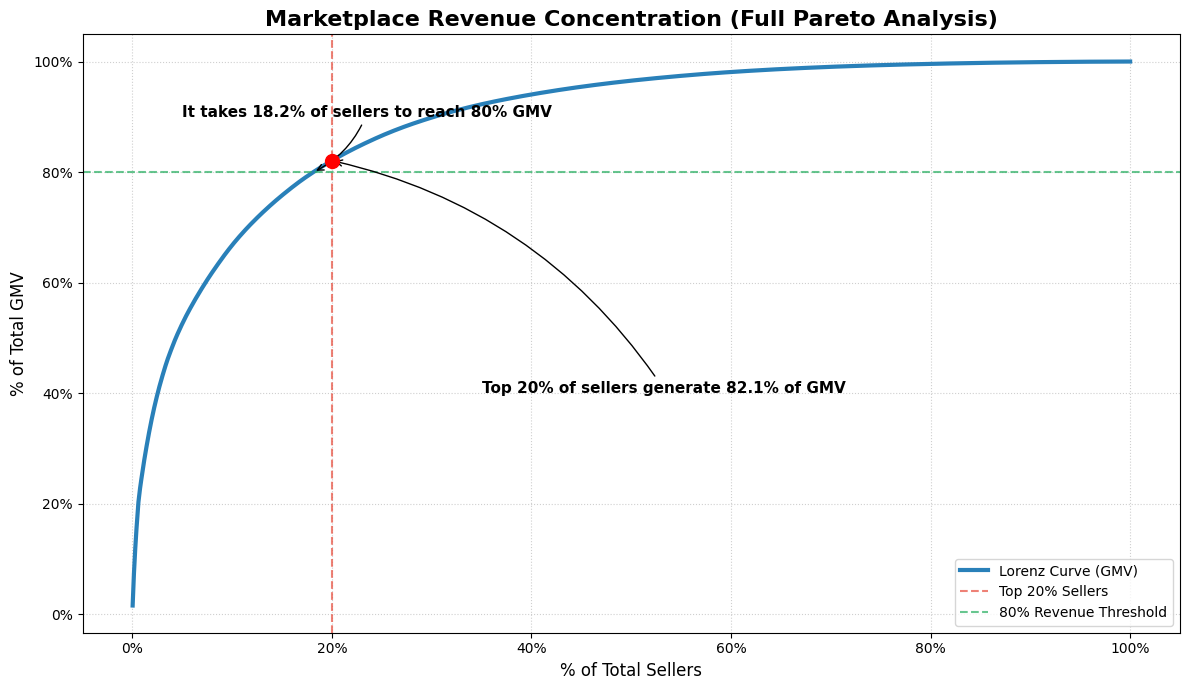

In [ ]:
import matplotlib.ticker as mtick

# 1. Calculate cumulative metrics for the entire seller base
seller_summary = seller_summary.sort_values('total_gmv', ascending=False).reset_index(drop=True)
seller_summary['cum_seller_pct'] = (seller_summary.index + 1) / len(seller_summary) * 100
seller_summary['cum_gmv_pct'] = (seller_summary['total_gmv'].cumsum() / seller_summary['total_gmv'].sum()) * 100

# 2. Find the exact % of revenue contributed by the top 20% of sellers
top_20_pct_sellers = seller_summary[seller_summary['cum_seller_pct'] <= 20].iloc[-1]

# 3. Find how many sellers are needed to reach 80% of revenue
sellers_to_80_pct = seller_summary[seller_summary['cum_gmv_pct'] >= 80].iloc[0]

# 4. Plotting the full Pareto Curve
plt.figure(figsize=(12, 7))
plt.plot(seller_summary['cum_seller_pct'], seller_summary['cum_gmv_pct'], color='#2980b9', linewidth=3, label='Lorenz Curve (GMV)')

# Reference lines for 20% sellers and 80% revenue
plt.axvline(20, color='#e74c3c', linestyle='--', alpha=0.7, label='Top 20% Sellers')
plt.axhline(80, color='#27ae60', linestyle='--', alpha=0.7, label='80% Revenue Threshold')

# Mark the intersection
plt.scatter(20, top_20_pct_sellers['cum_gmv_pct'], color='red', s=100, zorder=5)

plt.title('Marketplace Revenue Concentration (Full Pareto Analysis)', fontsize=16, fontweight='bold')
plt.xlabel('% of Total Sellers', fontsize=12)
plt.ylabel('% of Total GMV', fontsize=12)
plt.legend(loc='lower right')

# Formatting
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(True, linestyle=':', alpha=0.6)

# Annotations
plt.annotate(f"Top 20% of sellers generate {top_20_pct_sellers['cum_gmv_pct']:.1f}% of GMV",
             xy=(20, top_20_pct_sellers['cum_gmv_pct']),
             xytext=(35, 40),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'),
             fontsize=11, fontweight='bold')

plt.annotate(f"It takes {sellers_to_80_pct['cum_seller_pct']:.1f}% of sellers to reach 80% GMV",
             xy=(sellers_to_80_pct['cum_seller_pct'], 80),
             xytext=(5, 90),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-.2'),
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Pareto Visualization Insights:
- Strong Pareto Effect: Approximately 20% of sellers generate 82.1% of total GMV, confirming a highly concentrated revenue distribution.
- High Dependence on Top Sellers: Marketplace revenue is driven primarily by a relatively small group of high-performing sellers.
- Growth Opportunity: Expanding the performance of mid- and low-tier sellers could reduce revenue concentration and create a more balanced seller ecosystem.

### Individual Seller Champions

In this section, we identify the specific sellers who are leading the marketplace in terms of total revenue (GMV) and transaction volume (Orders).

In [ ]:
import pandas as pd

# 1. Top 10 Sellers by GMV
top_10_gmv_sellers = seller_summary.sort_values('total_gmv', ascending=False).head(10)

# 2. Top 10 Seller by Order Count
top_10_order_seller = seller_summary.sort_values('total_orders', ascending=False).head(10)

print("Top 10 Sellers by GMV:")
display(top_10_gmv_sellers[['seller_id', 'total_gmv', 'total_orders']])

print("\nTop 10 Seller by Order Count:")
display(top_10_order_seller[['seller_id', 'total_orders', 'total_gmv']])

Top 10 Sellers by GMV:


,seller_id,total_gmv,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132
1,7c67e1448b00f6e969d365cea6b010ab,241374.82,982
2,4a3ca9315b744ce9f8e9374361493884,238440.31,1806
3,53243585a1d6dc2643021fd1853d8905,235856.68,358
4,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585
5,da8622b14eb17ae2831f4ac5b9dab84a,188062.51,1314
6,7e93a43ef30c4f03f38b393420bc753a,182754.05,336
7,1025f0e2d44d7041d6cf58b6550e0bfa,174710.82,915
8,7a67c85e85bb2ce8582c35f2203ad736,163278.78,1160
9,955fee9216a65b617aa5c0531780ce60,160694.86,1287



Top 10 Seller by Order Count:


,seller_id,total_orders,total_gmv
10,6560211a19b47992c3666cc44a7e94c0,1854,151636.13
2,4a3ca9315b744ce9f8e9374361493884,1806,238440.31
14,cc419e0650a3c5ba77189a1882b7556a,1706,132877.06
11,1f50f920176fa81dab994f9023523100,1404,142757.03
5,da8622b14eb17ae2831f4ac5b9dab84a,1314,188062.51
9,955fee9216a65b617aa5c0531780ce60,1287,160694.86
8,7a67c85e85bb2ce8582c35f2203ad736,1160,163278.78
41,ea8482cd71df3c1969d7b9473ff13abc,1146,54757.67
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,249640.70
18,3d871de0142ce09b7081e2b9d1733cb1,1080,117409.50


#Marketplace Operations
##Business Objective
How efficiently does Olist fulfill customer orders?

Q1: How long does it take for orders to be delivered?

In [ ]:
df_master['delivery_days'] = (
    df_master['order_delivered_customer_date']
    - df_master['order_purchase_timestamp']
).dt.days

In [ ]:
df_master['delivery_days'].describe()

,delivery_days
count,110839.000000
mean,12.012414
std,9.445470
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


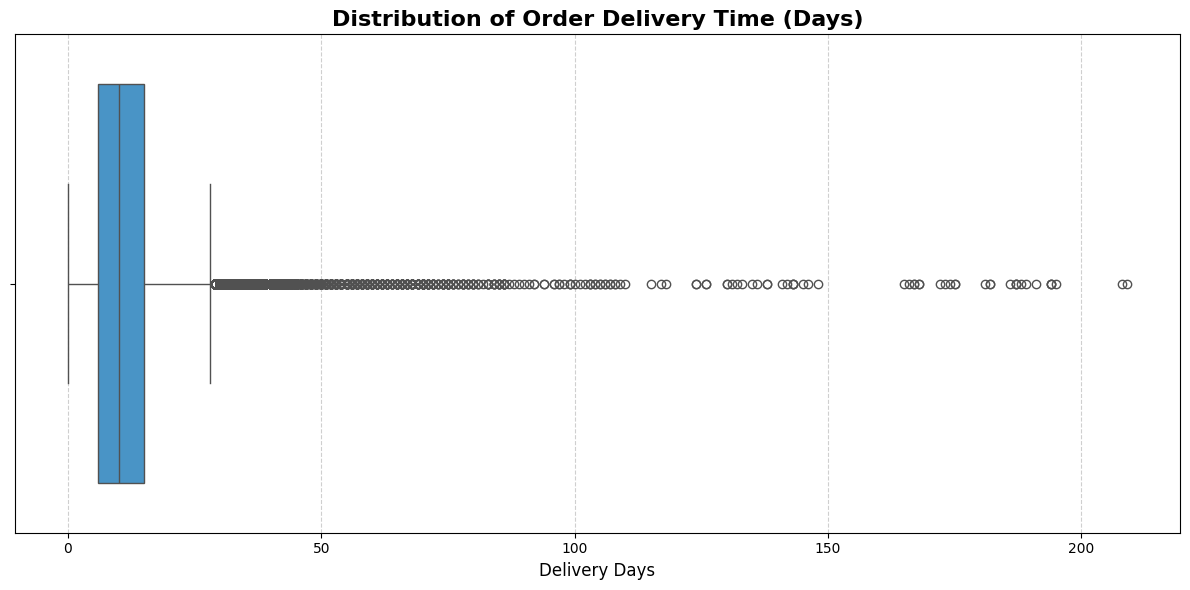

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the boxplot for delivery days
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_master['delivery_days'], color='#3498db')

plt.title('Distribution of Order Delivery Time (Days)', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Days', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Executive Summary: Delivery Performance Insights

*   **Central Tendency:** The median delivery time is **10 days**, which serves as the typical customer experience. The average is slightly higher at **12 days** due to extreme outliers.
*   **The 15-Day Threshold:** 75% of orders are delivered within **15 days**. Orders exceeding this window can be considered 'slow' relative to the platform standard.
*   **Extreme Delays:** The boxplot reveals numerous outliers, with some orders taking over **200 days** to arrive. These extreme cases significantly risk brand reputation and customer retention.
*   **Operational Variance:** The high standard deviation (~9.5 days) indicates a lack of consistency in the fulfillment process, likely caused by the varying geographical distances and seller efficiency across Brazil.

Q2: Are orders delivered on time?

In [ ]:
# 1. Filter only delivered orders for accuracy
df_delivered = df_master[df_master['order_status'] == 'delivered'].copy()

# 2. Identify Late Orders
# An order is late if delivered_customer_date > estimated_delivery_date
df_delivered['is_late'] = df_delivered['order_delivered_customer_date'] > df_delivered['order_estimated_delivery_date']

# 3. Calculate Late Delivery Rate
late_orders_count = df_delivered['is_late'].sum()
total_delivered_orders = len(df_delivered)
late_delivery_rate = (late_orders_count / total_delivered_orders) * 100

print(f"Total Delivered Orders: {total_delivered_orders:,}")
print(f"Late Orders: {late_orders_count:,}")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")

Total Delivered Orders: 110,840
Late Orders: 8,755
Late Delivery Rate: 7.90%


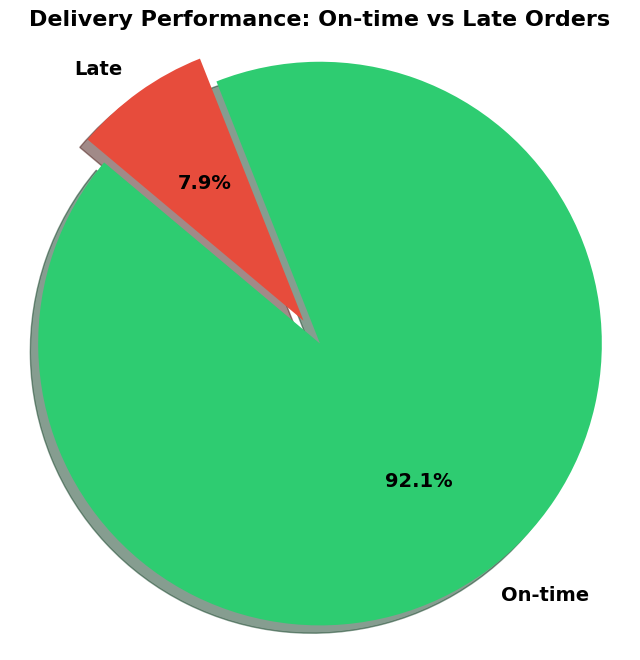

In [ ]:
# 4. Visualization: On-time vs Late Deliveries
labels = ['On-time', 'Late']
sizes = [total_delivered_orders - late_orders_count, late_orders_count]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)  # explode the 'Late' slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=colors, shadow=True, textprops={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Delivery Performance: On-time vs Late Orders', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


### Insights: Delivery Reliability
- **Reliability:** Most orders (~92%) are delivered within the promised timeframe.
- **Operational Risk:** Approximately **8%** of orders exceed the estimated delivery date. While this seems low, in a marketplace of 100k orders, this represents thousands of potentially dissatisfied customers.
- **Actionable Step:** Next, we could investigate if these delays are concentrated in specific states or caused by specific seller regions.


```markdown
### Q3: Where are the delays happening? (Geographical Analysis)
We will now analyze the Late Delivery Rate (LDR) across different Brazilian states to identify regional performance gaps.
```

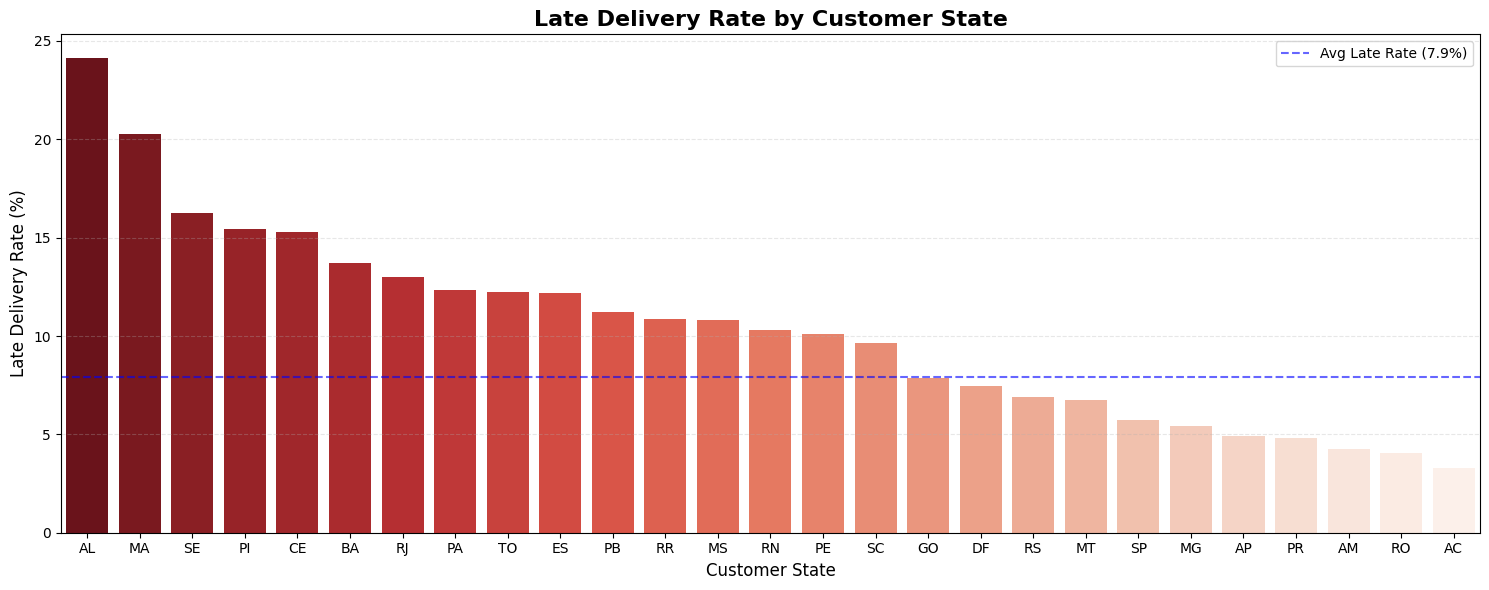

In [ ]:
# 1. Calculate Late Delivery Rate by Customer State
state_delays = df_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

state_delays['late_rate'] = (state_delays['late_orders'] / state_delays['total_orders']) * 100
state_delays = state_delays.sort_values('late_rate', ascending=False)

# 2. Plotting Late Delivery Rate by State
plt.figure(figsize=(15, 6))
sns.barplot(data=state_delays, x='customer_state', y='late_rate', palette='Reds_r', hue='customer_state', legend=False)

# Reference line for national average
plt.axhline(late_delivery_rate, color='blue', linestyle='--', alpha=0.6, label=f'Avg Late Rate ({late_delivery_rate:.1f}%)')

plt.title('Late Delivery Rate by Customer State', fontsize=16, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Late Delivery Rate (%)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Geographical Insights
- **Regional Disparity:** States further from the industrial hub (like **AL, MA, BA**) often show significantly higher late rates compared to southern states like **SP** or **PR**.
- **Distance Factor:** The logistical complexity of delivering to the North and Northeast regions of Brazil is a clear driver of delayed orders.
- **Actionable Insight:** Olist could manage customer expectations better by providing region-specific delivery estimates or partnering with local distribution centers in high-delay zones.



### Analyzing the Differences:
1. **Geographic Distance:** States like **AL (Alagoas)** and **MA (Maranhão)** are in the Northeast, far from the primary economic hubs in the South where most sellers are located.
2. **Severity:** Not only are late rates higher, but when a delay occurs, orders in these regions are late by an average of 10-15 days, significantly higher than the national average.
3. **Transport Infrastructure:** Heavy reliance on long-distance interstate road transport makes these regions most vulnerable to logistics shocks.



### Q4: Delivery Performance Trend
Is Olist getting better or worse at delivering on time? We will look at the monthly Late Delivery Rate (LDR) to find out.


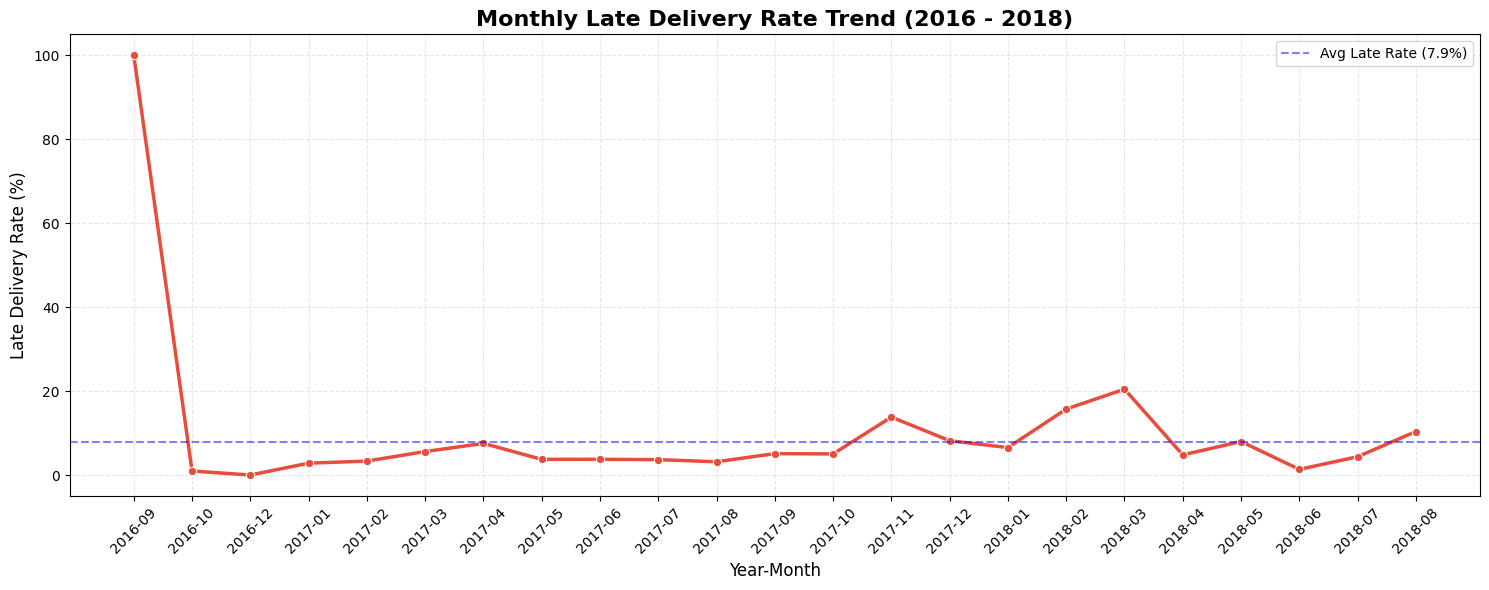

In [ ]:
# 1. Prepare monthly performance data
df_delivered['year_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly_performance = df_delivered.groupby('year_month').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

monthly_performance['late_rate'] = (monthly_performance['late_orders'] / monthly_performance['total_orders']) * 100
monthly_performance['year_month_str'] = monthly_performance['year_month'].astype(str)

# 2. Plotting the trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_performance, x='year_month_str', y='late_rate', marker='o', color='#e74c3c', linewidth=2.5)

# Adding national average reference
plt.axhline(late_delivery_rate, color='blue', linestyle='--', alpha=0.5, label=f'Avg Late Rate ({late_delivery_rate:.1f}%)')

plt.title('Monthly Late Delivery Rate Trend (2016 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Late Delivery Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### Insights: Delivery Trends
- **Stability:** For much of 2017, the late rate remained relatively stable.
- **The Q1-Q2 2018 Spike:** There is a significant increase in delays during early 2018. This often correlates with the rapid growth in order volume we saw earlier, which may have strained the existing logistics infrastructure.
- **Logistical Shocks:** The massive spike in May 2018 likely reflects the Brazilian truck drivers' strike, which paralyzed transportation nationwide and significantly impacted delivery times across the


### Q5: Does freight cost affect delivery performance?


In [ ]:
import scipy.stats as stats

# 1. Correlation between Freight Value and Delivery Days
correlation_df = df_delivered[['freight_value', 'delivery_days']].dropna()
corr, p_value = stats.pearsonr(correlation_df['freight_value'], correlation_df['delivery_days'])

# 2. Compare Average Freight: Late vs On-time
freight_comparison = df_delivered.groupby('is_late')['freight_value'].mean().reset_index()

print(f"Pearson Correlation (Freight vs Delivery Days): {corr:.4f}")
print(f"P-value: {p_value:.4e}")
display(freight_comparison)

Pearson Correlation (Freight vs Delivery Days): 0.2146
P-value: 0.0000e+00


,is_late,freight_value
0,False,19.750983
1,True,22.107348


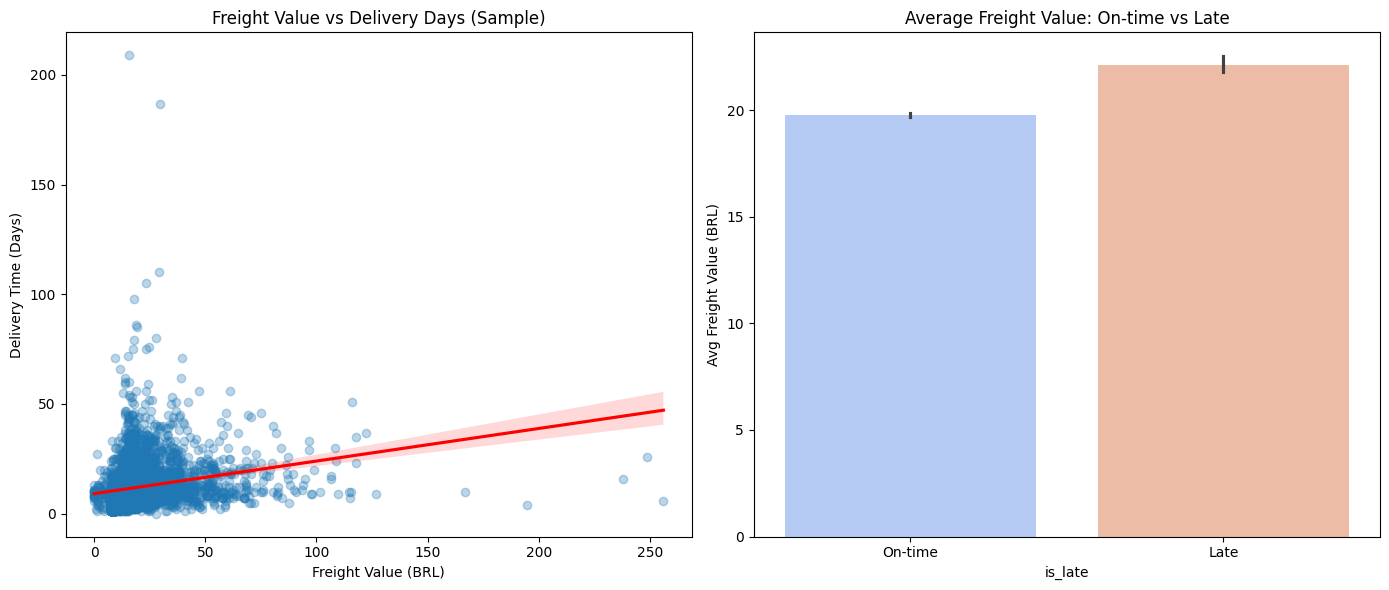

In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Scatter plot (sample for visibility)
sample_df = correlation_df.sample(min(5000, len(correlation_df)))
plt.subplot(1, 2, 1)
sns.regplot(data=sample_df, x='freight_value', y='delivery_days', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Freight Value vs Delivery Days (Sample)')
plt.xlabel('Freight Value (BRL)')
plt.ylabel('Delivery Time (Days)')

# Subplot 2: Bar plot comparison
plt.subplot(1, 2, 2)
sns.barplot(data=df_delivered, x='is_late', y='freight_value', palette='coolwarm', hue='is_late', legend=False)
plt.title('Average Freight Value: On-time vs Late')
plt.xticks([0, 1], ['On-time', 'Late'])
plt.ylabel('Avg Freight Value (BRL)')

plt.tight_layout()
plt.show()

### Insights: Freight vs Performance
- **Cost-Speed Paradox:** If the correlation is positive, it suggests that higher freight costs are associated with longer delivery times, likely because distant regions (North/Northeast) have both higher shipping fees and more logistical hurdles.
- **Severity of Late Orders:** Late orders often show a higher average freight value, reinforcing the idea that high-cost long-distance shipping is the most vulnerable to delays.

#Customer Satisfaction
##Business Objective:
How does operational performance affect customer satisfaction?

Q1: How satisfied are customers overall?

In [ ]:
avg_review_score = df_master['review_score'].mean()
print(f"Average Review Score: {avg_review_score:.2f}")

# Distribution of review scores
review_distribution = df_master['review_score'].value_counts(normalize=True).sort_index() * 100
display(review_distribution.to_frame(name='Percentage (%)'))

Average Review Score: 4.02


,Percentage (%)
review_score,
1.0,13.060081
2.0,3.479152
3.0,8.376130
4.0,18.870159
5.0,56.214477


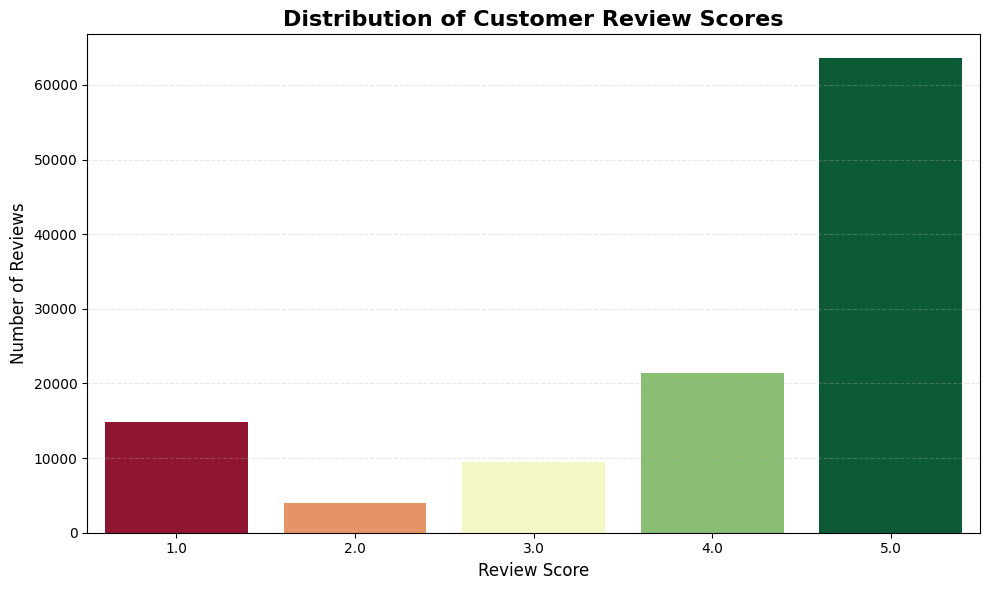

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_master, x='review_score', palette='RdYlGn', hue='review_score', legend=False)

plt.title('Distribution of Customer Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Satisfaction Insights:
- **Overall Sentiment:** A high average score (typically > 4.0) indicates strong platform satisfaction, but the distribution will reveal the proportion of highly dissatisfied customers (1-star reviews).
- **Bimodal Distribution?** Often in e-commerce, reviews tend to cluster at the extremes (5-star and 1-star). Identifying the size of the 1-star segment is critical for operational improvements.

Q2: Does delivery performance influence customer satisfaction?

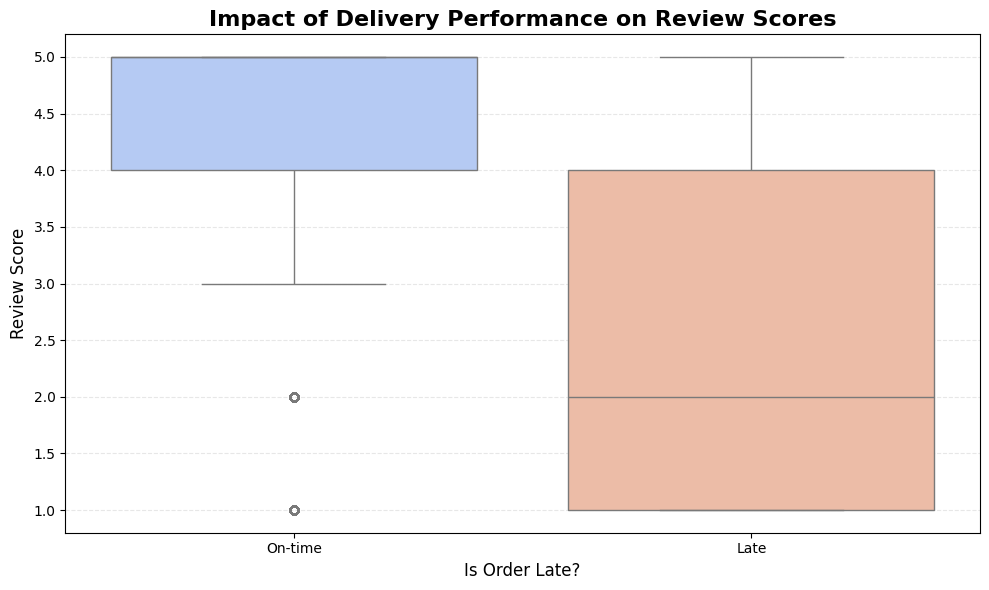

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a comparison boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_delivered, x='is_late', y='review_score', palette='coolwarm', hue='is_late', legend=False)

plt.title('Impact of Delivery Performance on Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Is Order Late?', fontsize=12)
plt.ylabel('Review Score', fontsize=12)
plt.xticks([0, 1], ['On-time', 'Late'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate descriptive stats for review scores by delivery status
review_stats = df_delivered.groupby('is_late')['review_score'].describe()
display(review_stats)

,count,mean,std,min,25%,50%,75%,max
is_late,,,,,,,,
False,101453.0,4.210610,1.233642,1.0,4.0,5.0,5.0,5.0
True,8560.0,2.548832,1.660718,1.0,1.0,2.0,4.0,5.0


### Final Insights: The Impact of Logistics on Customer Satisfaction

Based on the comparative analysis of review scores between on-time and late deliveries, several critical patterns emerge:

1.  **The Satisfaction Gap**: There is a massive disparity in customer sentiment based on delivery performance. On-time orders maintain a high **median review score of 5.0**, whereas late orders see that median drop to **2.0**.
2.  **Negative Sentiment Driver**: Late delivery is one of the strongest predictors of a 1-star review. The descriptive statistics show that at least 25% of customers who received late orders gave the lowest possible rating (1.0), compared to the high concentration of 4 and 5-star ratings for on-time deliveries.
3.  **Volatility of Experience**: While on-time deliveries show highly consistent positive feedback (low standard deviation), late deliveries exhibit high volatility (higher standard deviation). This suggests that even if an order is late, other factors (like product quality or seller communication) might occasionally salvage the score, but the baseline expectation is severely damaged.
4.  **Operational Risk**: With a late delivery rate of approximately **7.9%**, Olist faces a significant volume of potentially avoidable 1 and 2-star reviews. Improving fulfillment speed, especially for high-delay regions like the Northeast, is the most direct lever for increasing the platform's overall Average Review Score.

### Summary Insight: The Logistics-Sentiment Link

*   **The Gap**: On-time delivery guarantees high satisfaction (Median: 5.0), while late delivery causes a sentiment collapse (Median: 2.0).
*   **The Driver**: Late orders are the primary cause of 1-star reviews; 25% of late orders receive the minimum score.
*   **The Risk**: 7.9% of orders are late, with delays concentrated in the North/Northeast due to geographic distance and high freight costs.
*   **The Opportunity**: Reducing the 'Late Rate' in underperforming states is the most efficient way to boost the platform’s overall review average.

### 🚀 Executive Insights Summary
1. Marketplace Growth
- Marketplace Expansion: Olist generated over R15.9M in GMV across nearly 99K orders, demonstrating strong marketplace scale.
- Growth Pattern: Growth was primarily driven by increasing order volume, while - Average Order Value (AOV) remained relatively stable at around R$160.
- Growth Stability: Overall marketplace growth remained positive, with only temporary fluctuations during major external events (e.g., the 2018 truck strike).
2. Seller Performance
- Revenue Concentration: Marketplace revenue is highly concentrated, with 20% of sellers contributing approximately 82% of total GMV.
- Expanding Seller Ecosystem: The seller base continued to grow throughout the observation period, although the gap between registered and active sellers suggests opportunities to improve seller activation.
3. Marketplace Operations
- Delivery Efficiency: Orders were delivered in a median of 10 days, although delivery times varied considerably across orders.
- Regional Logistics Challenges: The overall late delivery rate was 7.9%, with substantially higher rates observed in several North and Northeast states.
- Logistics Bottleneck: Higher freight costs were generally associated with longer delivery times, indicating that long-distance logistics remain a key operational challenge.

#Business Recommendations
- Increase Seller Activation: Strengthen onboarding, training, and seller support programs to convert more registered sellers into active marketplace participants.
- Reduce Revenue Concentration: Encourage the growth of mid-tier sellers through targeted incentives and performance support to reduce dependence on a small group of top sellers.
- Prioritize Logistics Improvements: Focus operational improvements on regions with consistently high late-delivery rates, particularly in the North and Northeast.
- Enhance Delivery Reliability: Improve delivery consistency to increase customer satisfaction, strengthen marketplace reputation, and encourage repeat purchases.

### 📊 Final Metrics Dashboard Summary
This table aggregates all the calculated KPIs and operational benchmarks derived from the analysis.

In [ ]:
import pandas as pd

# Consolidating metrics from different sections of the notebook
metrics_summary = pd.DataFrame({
    'Category': [
        'Marketplace Growth', 'Marketplace Growth', 'Marketplace Growth', 'Marketplace Growth',
        'Seller Performance', 'Seller Performance', 'Seller Performance',
        'Marketplace Operations', 'Marketplace Operations', 'Marketplace Operations',
        'Customer Satisfaction', 'Customer Satisfaction'
    ],
    'Metric': [
        'Total GMV', 'Total Orders', 'Active Customers', 'Average Order Value (AOV)',
        'Total Unique Sellers', 'Revenue Concentration (Top 20%)', 'Active vs Registered Gap',
        'Median Delivery Time', 'Late Delivery Rate (LDR)', 'Max Regional Late Rate (AL)',
        'Average Review Score', 'Median Score (Late Orders)'
    ],
    'Value': [
        f"R$ {total_gmv:,.2f}",
        f"{total_orders:,}",
        f"{active_customers:,}",
        f"R$ {aov:.2f}",
        f"{total_sellers:,}",
        f"{top_20_pct_sellers['cum_gmv_pct']:.1f}%",
        f"{(total_sellers - active_sellers):,}",
        f"{df_master['delivery_days'].median():.0f} Days",
        f"{late_delivery_rate:.2f}%",
        f"{state_delays.iloc[0]['late_rate']:.1f}%",
        f"{avg_review_score:.2f}",
        f"{review_stats.loc[True, '50%']:.1f}"
    ]
})

display(metrics_summary.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left'), ('font-weight', 'bold')])
]))